In [7]:
# =====================================
# ENTRENAR MODELO Y GUARDAR
# =====================================
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# One-hot
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Modelo CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar
model.fit(X_train, y_train, epochs=3)

# Guardar
model.save("modelo_numeros.h5")

print("✅ Modelo guardado")

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.9612 - loss: 0.1267
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9872 - loss: 0.0407
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 24ms/step - accuracy: 0.9917 - loss: 0.0265


✅ Modelo guardado


✅ Modelo cargado


Saving WhatsApp Image 2026-04-27 at 8.09.56 PM.jpeg to WhatsApp Image 2026-04-27 at 8.09.56 PM.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

🔢 Número detectado: 4


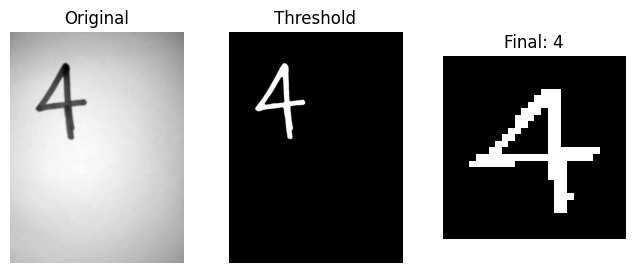

In [8]:
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import cv2

# ==============================
# CARGAR MODELO
# ==============================
model = load_model("modelo_numeros.h5")
print("✅ Modelo cargado")

# ==============================
# SUBIR IMAGEN
# ==============================
uploaded = files.upload()
image_name = next(iter(uploaded))

# ==============================
# PREPROCESAMIENTO SIMPLE (CLAVE)
# ==============================
img = Image.open(image_name).convert('L')

# 🔥 aumentar contraste SIN destruir
img = ImageOps.autocontrast(img)

img = np.array(img)

# 🔥 threshold suave
_, thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY_INV)

# 🔥 engrosar ligeramente
kernel = np.ones((2,2), np.uint8)
thresh = cv2.dilate(thresh, kernel, iterations=1)

# ==============================
# CONTORNOS
# ==============================
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("❌ No se detectó número")
else:
    c = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(c)
    digit = thresh[y:y+h, x:x+w]

    # ==============================
    # REDUCIR
    # ==============================
    SIZE = 20
    digit = cv2.resize(digit, (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)

    # ==============================
    # CENTRAR
    # ==============================
    canvas = np.zeros((28,28))
    x_offset = (28 - SIZE)//2
    y_offset = (28 - SIZE)//2
    canvas[y_offset:y_offset+SIZE, x_offset:x_offset+SIZE] = digit

    # normalizar
    img_array = canvas / 255.0
    img_array = img_array.reshape(1,28,28,1)

    # ==============================
    # PREDICCIÓN
    # ==============================
    pred = model.predict(img_array)
    number = np.argmax(pred)

    print(f"\n🔢 Número detectado: {number}")

    # ==============================
    # MOSTRAR
    # ==============================
    plt.figure(figsize=(8,3))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Threshold")
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title(f"Final: {number}")
    plt.imshow(canvas, cmap='gray')
    plt.axis('off')

    plt.show()